# 04 - Free-streaming suppression of P(k)

The daughter is born with speed v = √(η(η+2))/(1+η), free-streams, and suppresses P(k) below its
free-streaming length. Checks, all against ΛCDM with the same neutrinos:

- **A1 shape:** P_accDM/P_ΛCDM → 1 on large scales and < 1 on small scales.
- **A2 f_acc:** more accDM, deeper suppression.
- **A3 η:** a warmer daughter suppresses more, and the cutoff moves to larger scales (smaller k).

Asserts are on trends, not magnitudes. The kick follows the mass, η = 10¹¹ GeV/m, as in the chains;
fiducial f_acc = 0.01, η = 0.1 (m = 10¹² GeV). κ = 12.1, a_t = 0.133.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from accdm_nb import accdm_params, lcdm_params, run_class, plot_style

plot_style()

K_NODES = np.logspace(-3, 0.9, 60)          # 1/Mpc; suppression is measured at k > 2
OUTPUT = {'output': 'mPk', 'P_k_max_1/Mpc': 10.0, 'z_max_pk': 0.0}
F_FID, ETA_FID = 0.01, 0.1


def pk(cosmo):
    return {'pk': np.array([cosmo.pk(k, 0.0) for k in K_NODES])}


runs = {}
def ratio(f_acc, eta):
    """P_accDM / P_ΛCDM at z = 0, with mass = 1e11 GeV / eta."""
    if (f_acc, eta) not in runs:
        out = run_class(accdm_params(f_acc, 1e11/eta, eta=eta, reionization_z_start_max=80, **OUTPUT), pk)
        assert 'error' not in out, out['error']
        runs[(f_acc, eta)] = out['pk']/PK_LCDM
    return runs[(f_acc, eta)]


def suppression(r):
    """1 - mean ratio at k > 2/Mpc."""
    return float(1 - np.mean(r[K_NODES > 2]))


def k_cut(r):
    """k where the ratio is halfway between 1 and its small-scale value."""
    target = 0.5*(1 + np.median(r[K_NODES > 2]))
    below = np.nonzero(r < target)[0]
    return float(K_NODES[below[0]]) if len(below) else np.inf


out = run_class(lcdm_params(**OUTPUT), pk)
assert 'error' not in out, out['error']
PK_LCDM = out['pk']

## A1 shape

In [2]:
r = ratio(F_FID, ETA_FID)
large = float(np.mean(r[K_NODES < 5e-3]))
print('f_acc = {:g}, eta = {:g}: large-scale ratio {:.4f}, small-scale suppression {:.3f}'.format(
    F_FID, ETA_FID, large, suppression(r)))
assert 0.97 < large < 1.03, 'large scales differ from ΛCDM'
assert suppression(r) > 0.02, 'no small-scale suppression'
print('A1 passed')

f_acc = 0.01, eta = 0.1: large-scale ratio 0.9854, small-scale suppression 0.032
A1 passed


## A2 f_acc

In [3]:
F_SEQ = [1e-4, 1e-3, 1e-2, 1e-1, 5e-1]
supp_f = [suppression(ratio(f, ETA_FID)) for f in F_SEQ]
for f, s in zip(F_SEQ, supp_f):
    print('f_acc = {:<7g} suppression {:.3f}'.format(f, s))
assert all(np.diff(supp_f) > 0), 'suppression not monotonic in f_acc'
print('A2 passed')

f_acc = 0.0001  suppression 0.000
f_acc = 0.001   suppression 0.003
f_acc = 0.01    suppression 0.032
f_acc = 0.1     suppression 0.263
f_acc = 0.5     suppression 0.702
A2 passed


## A3 η

In [4]:
E_SEQ = [1e-7, 1e-5, 1e-3, 1e-1, 1.0]
supp_e = [suppression(ratio(F_FID, e)) for e in E_SEQ]
kcut_e = [k_cut(ratio(F_FID, e)) for e in E_SEQ]
for e, s, kc in zip(E_SEQ, supp_e, kcut_e):
    print('eta = {:<6g} (m = {:.0e} GeV)  suppression {:.4f}  k_cut {:.3g} /Mpc'.format(e, 1e11/e, s, kc))
assert supp_e[0] < supp_e[1] < supp_e[2], 'suppression not monotonic in eta'
assert kcut_e[0] > kcut_e[1] > kcut_e[2], 'cutoff does not move to smaller k as eta grows'
print('A3 passed')

eta = 1e-07  (m = 1e+18 GeV)  suppression 0.0219  k_cut 2.02 /Mpc
eta = 1e-05  (m = 1e+16 GeV)  suppression 0.0299  k_cut 0.24 /Mpc
eta = 0.001  (m = 1e+14 GeV)  suppression 0.0303  k_cut 0.0244 /Mpc
eta = 0.1    (m = 1e+12 GeV)  suppression 0.0320  k_cut 0.00249 /Mpc
eta = 1      (m = 1e+11 GeV)  suppression 0.0483  k_cut 0.001 /Mpc
A3 passed


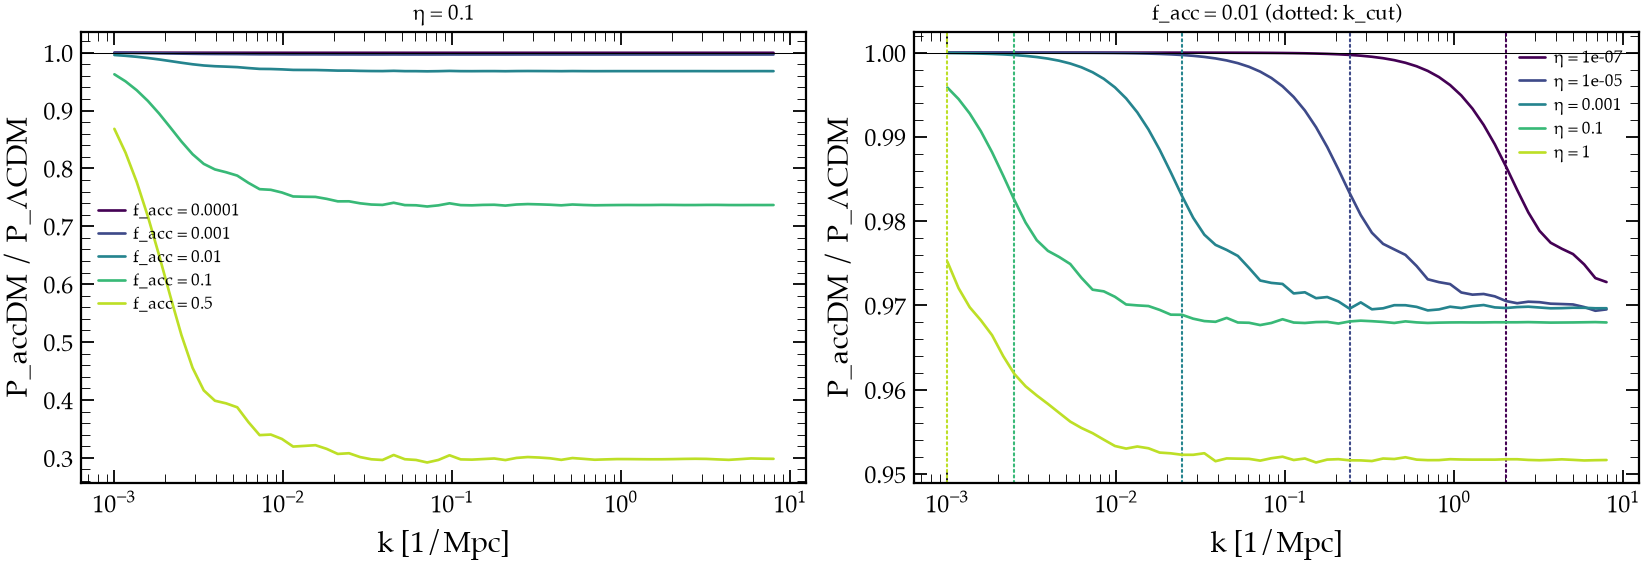

In [5]:
colors = plt.cm.viridis(np.linspace(0, 0.9, 5))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for f, c in zip(F_SEQ, colors):
    axes[0].semilogx(K_NODES, ratio(f, ETA_FID), color=c, label='f_acc = {:g}'.format(f))
axes[0].set_title('η = {:g}'.format(ETA_FID), fontsize=10)
for e, kc, c in zip(E_SEQ, kcut_e, colors):
    axes[1].semilogx(K_NODES, ratio(F_FID, e), color=c, label='η = {:g}'.format(e))
    if np.isfinite(kc):
        axes[1].axvline(kc, color=c, ls=':', lw=1)
axes[1].set_title('f_acc = {:g} (dotted: k_cut)'.format(F_FID), fontsize=10)
for ax in axes:
    ax.axhline(1, color='k', lw=0.5)
    ax.set_xlabel('k [1/Mpc]')
    ax.set_ylabel('P_accDM / P_ΛCDM')
    ax.legend(fontsize=8)
plt.show()